# E3 Experiment Analysis

In [1]:
import pathlib
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

In [27]:
# NOTE! the names are different than the config file runs! this is for reporting purposes...
EXPERIMENTS = {
    # "e3_1.yaml": "Experiment 3.1",
    # "e3_2.yaml": "Experiment 3.2",
    "e3_3_quat_naive": "Experiment 3.0",
    "e3_3_a_quat_naive": "Experiment 3.1",
}

runs_dir = pathlib.Path("./runs")
conf_dir = pathlib.Path("./conf/e3")

In [28]:
def load_config(exp_name: str) -> OmegaConf:
    """Load config for experiment, resolving defaults."""
    # Handle the .yaml suffix in experiment names
    config_name = exp_name.replace(".yaml", "") + ".yaml"
    config_path = conf_dir / config_name
    if not config_path.exists():
        return None
    cfg = OmegaConf.load(config_path)
    # Resolve defaults if present
    if "defaults" in cfg:
        base_name = cfg.defaults[0]
        base_cfg = OmegaConf.load(conf_dir / f"{base_name}.yaml")
        cfg = OmegaConf.merge(base_cfg, cfg)
    return cfg

In [29]:
def load_event_accumulator(run_path: pathlib.Path) -> EventAccumulator:
    subdirs = list(run_path.iterdir())
    if not subdirs:
        raise ValueError(f"No subdirectories in {run_path}")
    event_dir = subdirs[0]
    ea = EventAccumulator(str(event_dir))
    ea.Reload()
    return ea

def get_scalar_series(ea, tag):
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]
    return steps, values

def get_final_scalar(ea, tag):
    events = ea.Scalars(tag)
    return events[-1].value

def get_scalar_at_epoch(ea, tag, target_epoch):
    """Get scalar value at a specific epoch (or closest available)."""
    events = ea.Scalars(tag)
    for e in events:
        if e.step == target_epoch:
            return e.value
    # If exact epoch not found, find closest
    closest = min(events, key=lambda e: abs(e.step - target_epoch))
    return closest.value

COMPARISON_EPOCH = 1000  # Epoch to compare across experiments

In [30]:
data = {}
for exp_name, exp_label in EXPERIMENTS.items():
    run_path = runs_dir / exp_name
    if not run_path.exists():
        print(f"Skipping {exp_name} - not found")
        continue
    ea = load_event_accumulator(run_path)
    cfg = load_config(exp_name)
    data[exp_name] = {"label": exp_label, "ea": ea, "cfg": cfg}
    print(f"Loaded {exp_name}")

Loaded e3_3_quat_naive
Loaded e3_3_a_quat_naive


In [31]:
# Inspect available tags from first experiment
first_exp = list(data.values())[0]["ea"]
print("Available scalar tags:")
for tag in first_exp.Tags()['scalars']:
    print(f"  {tag}")

Available scalar tags:
  loss_all/train
  loss_translation/train
  loss_rotation/train
  angular_error/train
  frobenius_norm/train
  translation_error/train
  loss_all/val
  loss_translation/val
  loss_rotation/val
  angular_error/val
  frobenius_norm/val
  translation_error/val
  translation_error/train_final
  angular_error/train_final
  translation_error/val_final
  angular_error/val_final
  translation_error/test
  angular_error/test


## Typst Table

In [45]:
print("#table(")
print("  columns: 14,")
print(f"  [Experiment], [Model], [Emb Size], [LR], [Loss], [Rot Rep], [λ Trans], [λ Frob], [Train Ang @{COMPARISON_EPOCH}], [Val Ang @{COMPARISON_EPOCH}], [Test Ang], [Train Trans @{COMPARISON_EPOCH}], [Val Trans @{COMPARISON_EPOCH}], [Test Trans],")
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    cfg = exp_data["cfg"]

    # Extract config values
    model_name = cfg.model.name if cfg else "N/A"
    emb_size = cfg.model.embedding_size if cfg else "N/A"
    lr = cfg.training.lr if cfg else "N/A"
    loss_fn = cfg.training.rotation_loss if cfg else "N/A"
    rot_rep = cfg.model.rotation_representation if cfg else "N/A"
    lambda_trans = cfg.training.lambda_translation if cfg else "N/A"
    lambda_frob = cfg.training.lambda_frobenius if cfg else "N/A"

    # Get angular error values at comparison epoch
    train_ang_err = get_scalar_at_epoch(ea, "angular_error/train", COMPARISON_EPOCH)
    val_ang_err = get_scalar_at_epoch(ea, "angular_error/val", COMPARISON_EPOCH)
    test_ang_err = get_final_scalar(ea, "angular_error/test")

    # Get translation error values at comparison epoch
    train_trans_err = get_scalar_at_epoch(ea, "translation_error/train", COMPARISON_EPOCH)
    val_trans_err = get_scalar_at_epoch(ea, "translation_error/val", COMPARISON_EPOCH)
    test_trans_err = get_final_scalar(ea, "translation_error/test")

    print(f"  [{label}], [{model_name}], [{emb_size}], [{lr}], [{loss_fn}], [{rot_rep}], [{lambda_trans}], [{lambda_frob}], [{train_ang_err:.2f}], [{val_ang_err:.2f}], [{test_ang_err:.2f}], [{train_trans_err:.4f}], [{val_trans_err:.4f}], [{test_trans_err:.4f}],")
print(")")

#table(
  columns: 14,
  [Experiment], [Model], [Emb Size], [LR], [Loss], [Rot Rep], [λ Trans], [λ Frob], [Train Ang @1000], [Val Ang @1000], [Test Ang], [Train Trans @1000], [Val Trans @1000], [Test Trans],
  [Experiment 3.0], [SiameseGCN], [64], [0.001], [mse], [quaternion], [1.0], [0.01], [8.33], [68.66], [73.56], [0.0507], [1.6807], [1.4896],
  [Experiment 3.1], [SiameseGCN], [64], [0.001], [mse], [quaternion], [0.1], [0.01], [2.28], [68.76], [67.51], [0.0573], [1.6795], [1.5461],
)


## Loss Curves

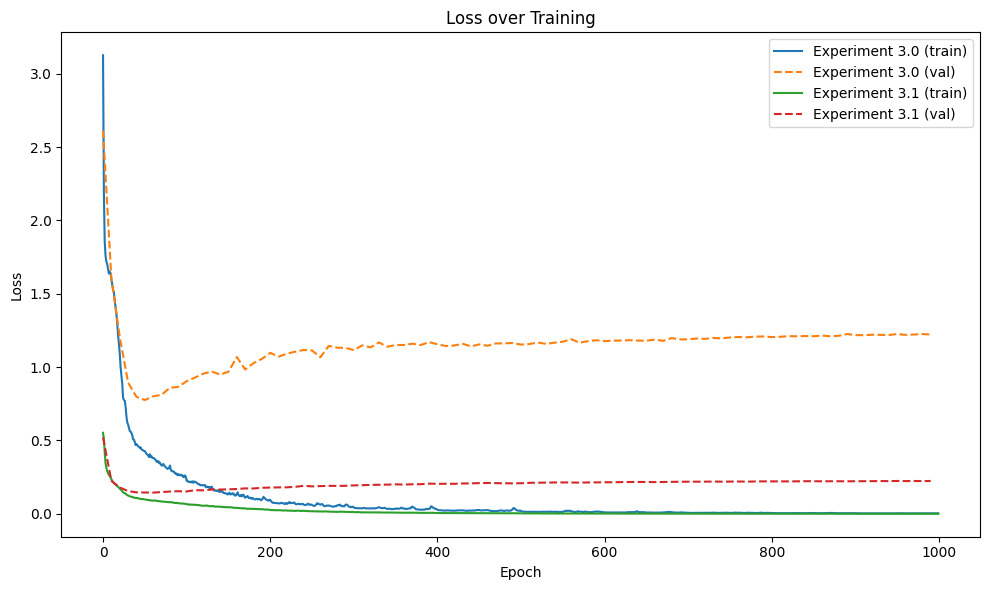

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "loss_all/train")
    ax.plot(steps, values, label=f"{label} (train)")
    steps, values = get_scalar_series(ea, "loss_all/val")
    ax.plot(steps, values, linestyle="--", label=f"{label} (val)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss over Training")
ax.legend()
plt.tight_layout()
plt.show()

## Angular Error Curves

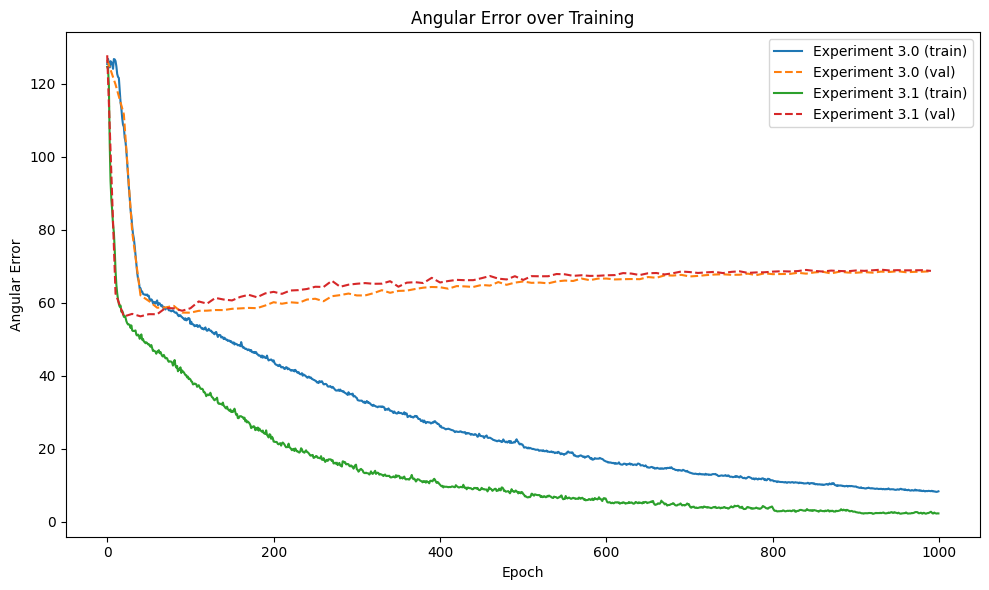

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "angular_error/train")
    ax.plot(steps, values, label=f"{label} (train)")
    steps, values = get_scalar_series(ea, "angular_error/val")
    ax.plot(steps, values, linestyle="--", label=f"{label} (val)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Angular Error")
ax.set_title("Angular Error over Training")
ax.legend()
plt.tight_layout()
plt.show()

## Translation Error Curves

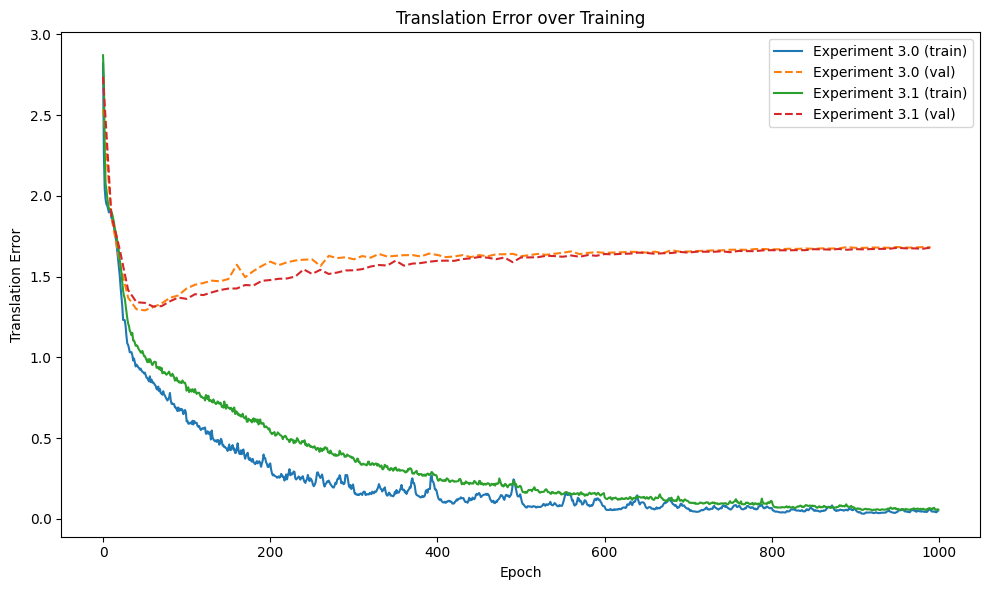

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "translation_error/train")
    ax.plot(steps, values, label=f"{label} (train)")
    steps, values = get_scalar_series(ea, "translation_error/val")
    ax.plot(steps, values, linestyle="--", label=f"{label} (val)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Translation Error")
ax.set_title("Translation Error over Training")
ax.legend()
plt.tight_layout()
plt.show()

## Angular Error (Training vs Validation Side-by-Side)

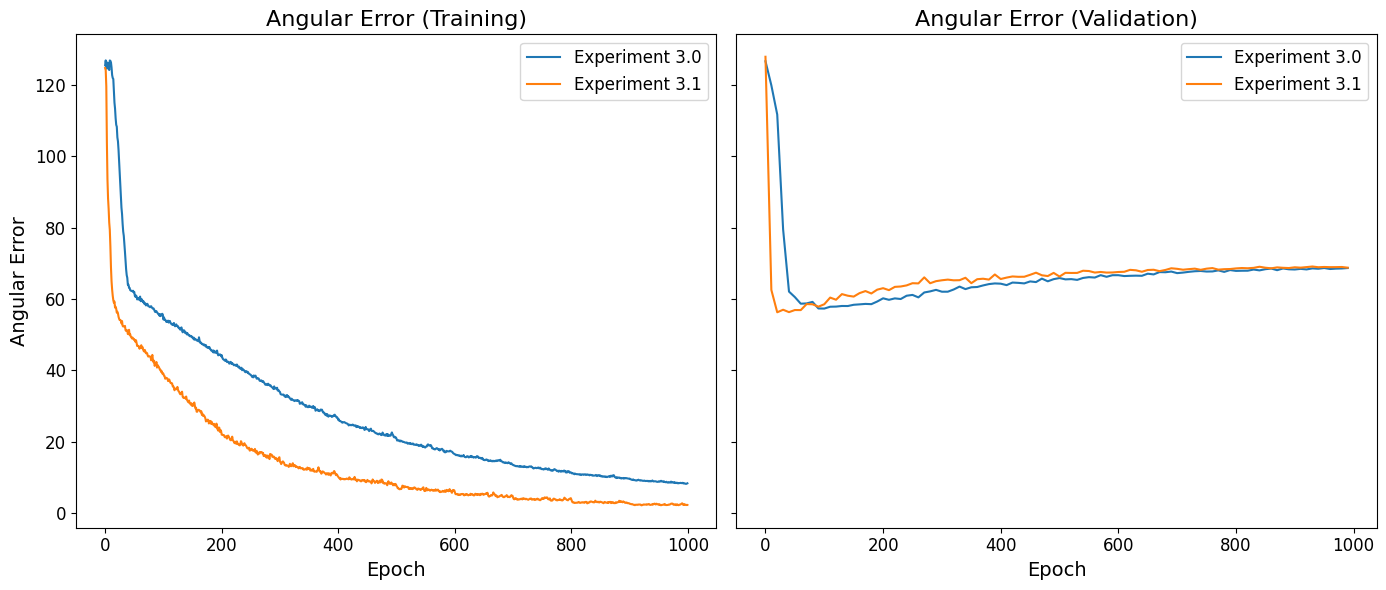

In [37]:
# Define consistent colors for each experiment
exp_colors = {exp_name: plt.cm.tab10(i) for i, exp_name in enumerate(data.keys())}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Training plot (left)
ax_train = axes[0]
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "angular_error/train")
    ax_train.plot(steps, values, label=label, color=exp_colors[exp_name])
ax_train.set_xlabel("Epoch", fontsize=14)
ax_train.set_ylabel("Angular Error", fontsize=14)
ax_train.set_title("Angular Error (Training)", fontsize=16)
ax_train.legend(fontsize=12)
ax_train.tick_params(axis='both', labelsize=12)

# Validation plot (right)
ax_val = axes[1]
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "angular_error/val")
    ax_val.plot(steps, values, label=label, color=exp_colors[exp_name])
ax_val.set_xlabel("Epoch", fontsize=14)
ax_val.set_title("Angular Error (Validation)", fontsize=16)
ax_val.legend(fontsize=12)
ax_val.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

## Translation Error (Training vs Validation Side-by-Side)

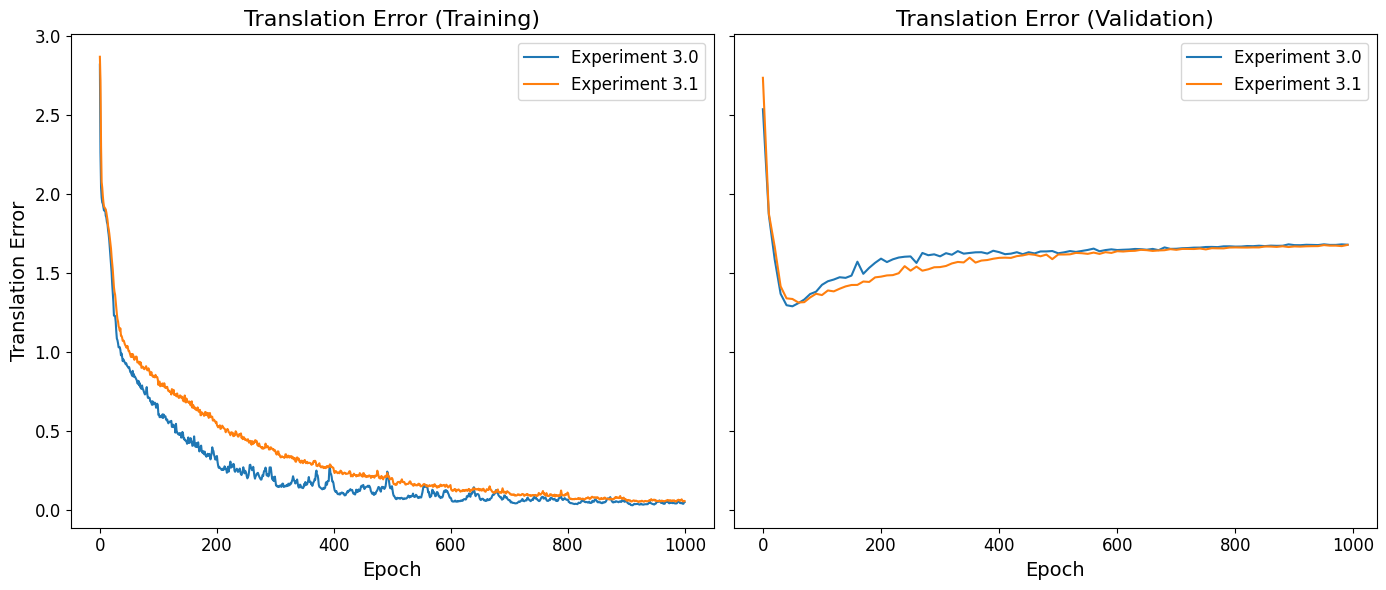

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Training plot (left)
ax_train = axes[0]
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "translation_error/train")
    ax_train.plot(steps, values, label=label, color=exp_colors[exp_name])
ax_train.set_xlabel("Epoch", fontsize=14)
ax_train.set_ylabel("Translation Error", fontsize=14)
ax_train.set_title("Translation Error (Training)", fontsize=16)
ax_train.legend(fontsize=12)
ax_train.tick_params(axis='both', labelsize=12)

# Validation plot (right)
ax_val = axes[1]
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "translation_error/val")
    ax_val.plot(steps, values, label=label, color=exp_colors[exp_name])
ax_val.set_xlabel("Epoch", fontsize=14)
ax_val.set_title("Translation Error (Validation)", fontsize=16)
ax_val.legend(fontsize=12)
ax_val.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

## Angular Error (Training Only)

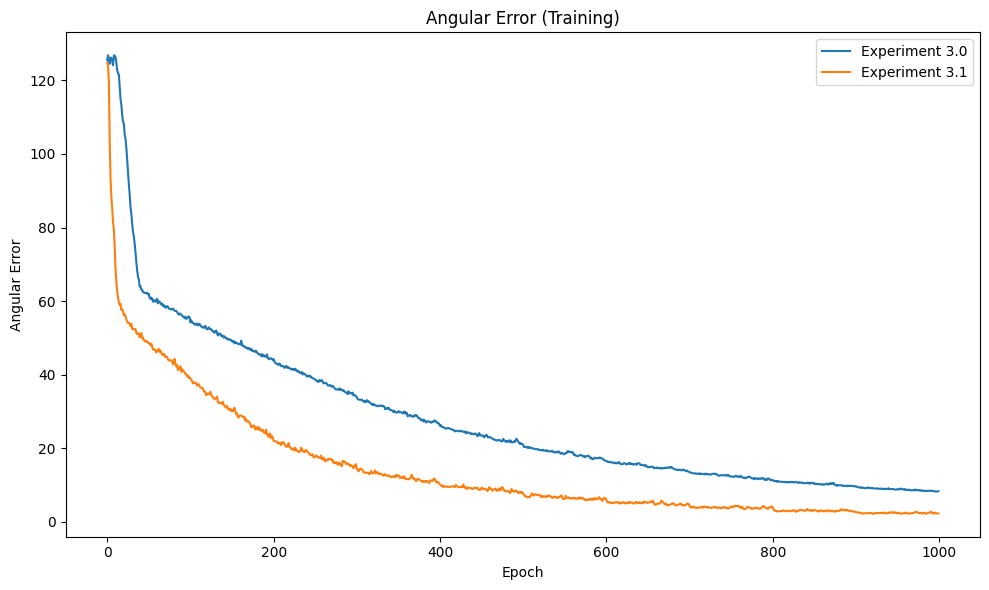

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "angular_error/train")
    ax.plot(steps, values, label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Angular Error")
ax.set_title("Angular Error (Training)")
ax.legend()
plt.tight_layout()
plt.show()

## Angular Error (Validation Only)

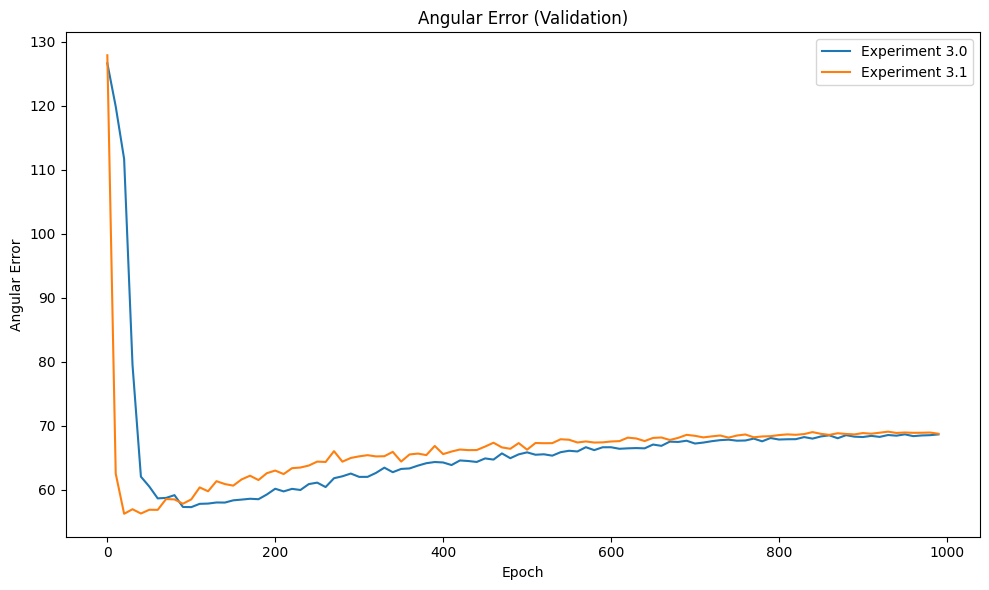

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "angular_error/val")
    ax.plot(steps, values, label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Angular Error")
ax.set_title("Angular Error (Validation)")
ax.legend()
plt.tight_layout()
plt.show()

## Angular Error at Epoch 500 (Bar Plot)

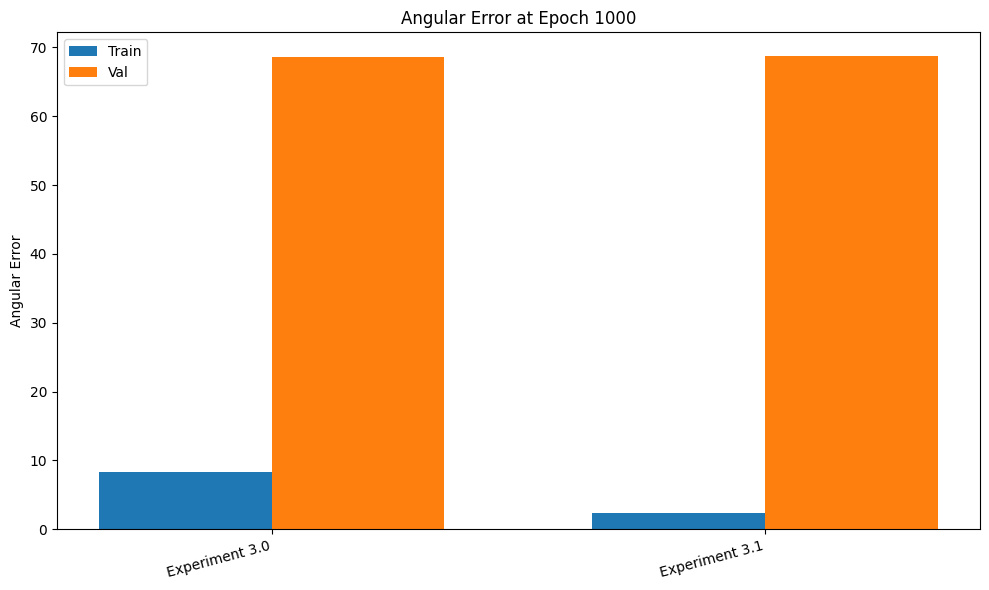

In [41]:
labels = []
train_errors = []
val_errors = []
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    labels.append(exp_data["label"])
    train_errors.append(get_scalar_at_epoch(ea, "angular_error/train", COMPARISON_EPOCH))
    val_errors.append(get_scalar_at_epoch(ea, "angular_error/val", COMPARISON_EPOCH))

import numpy as np
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, train_errors, width, label='Train')
ax.bar(x + width/2, val_errors, width, label='Val')
ax.set_ylabel("Angular Error")
ax.set_title(f"Angular Error at Epoch {COMPARISON_EPOCH}")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## Final Test Angular Error (Bar Plot)

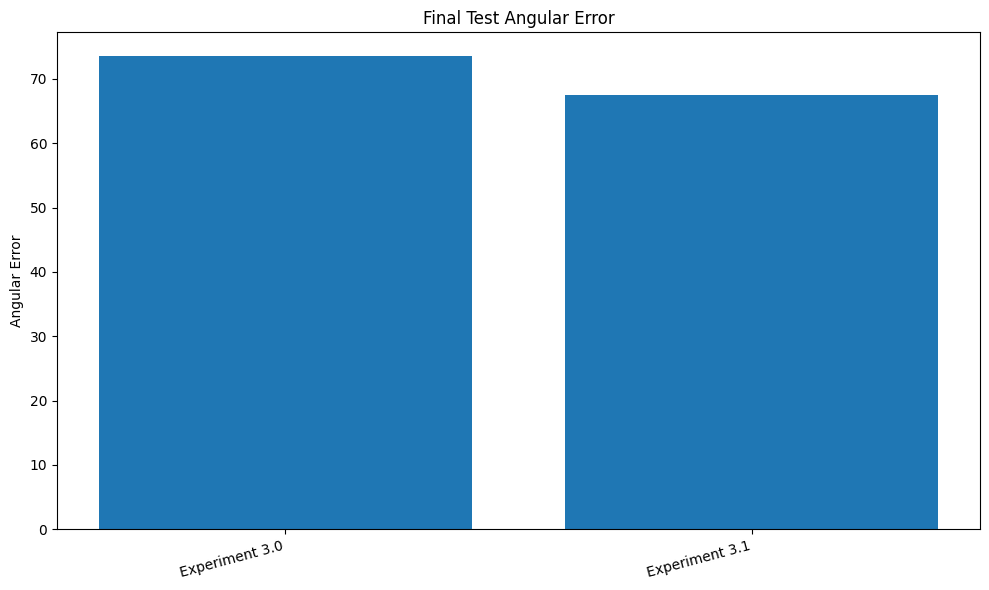

In [42]:
labels = []
test_errors = []
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    labels.append(exp_data["label"])
    test_errors.append(get_final_scalar(ea, "angular_error/test"))

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(labels, test_errors)
ax.set_ylabel("Angular Error")
ax.set_title("Final Test Angular Error")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Translation Error at Epoch 500 (Bar Plot)

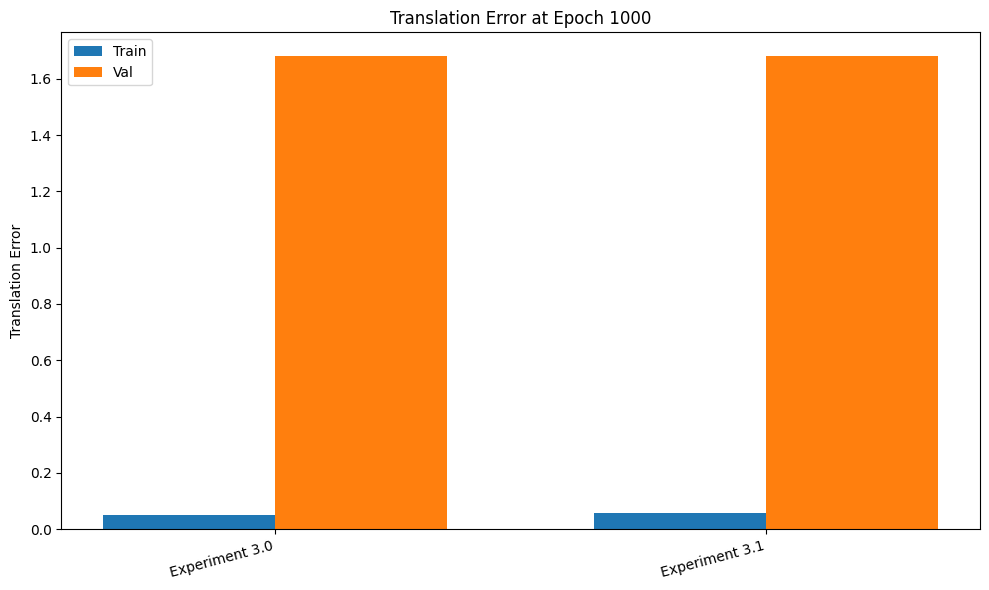

In [43]:
labels = []
train_errors = []
val_errors = []
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    labels.append(exp_data["label"])
    train_errors.append(get_scalar_at_epoch(ea, "translation_error/train", COMPARISON_EPOCH))
    val_errors.append(get_scalar_at_epoch(ea, "translation_error/val", COMPARISON_EPOCH))

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, train_errors, width, label='Train')
ax.bar(x + width/2, val_errors, width, label='Val')
ax.set_ylabel("Translation Error")
ax.set_title(f"Translation Error at Epoch {COMPARISON_EPOCH}")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## Final Test Translation Error (Bar Plot)

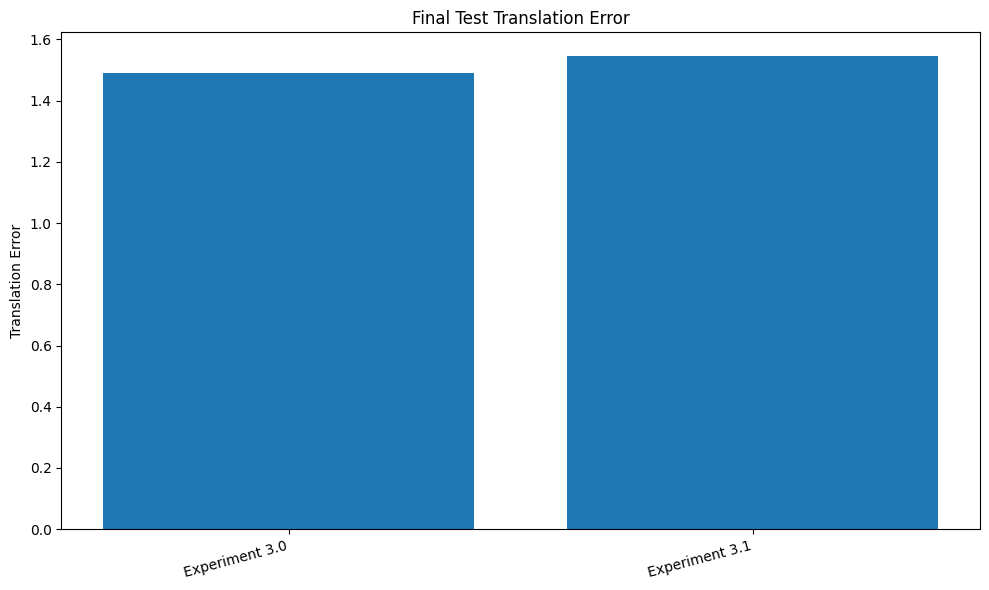

In [44]:
labels = []
test_errors = []
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    labels.append(exp_data["label"])
    test_errors.append(get_final_scalar(ea, "translation_error/test"))

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(labels, test_errors)
ax.set_ylabel("Translation Error")
ax.set_title("Final Test Translation Error")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()